In [47]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [48]:
import yfinance as yf

ticker = "GC=F"

gold_data = yf.download(ticker, start="2000-01-01", end=None, progress=False)

In [49]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

In [50]:
gold_data

,Date,Close,High,Low,Open,Volume
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0
1,2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...,...
6177,2025-04-15,3218.699951,3218.699951,3214.000000,3216.000000,390
6178,2025-04-16,3326.600098,3334.899902,3238.300049,3238.300049,1874
6179,2025-04-17,3308.699951,3345.000000,3287.800049,3345.000000,824
6180,2025-04-21,3406.199951,3418.500000,3342.199951,3342.199951,824


In [51]:
gold_data["Pct_Change"] = gold_data["Close"].pct_change()

In [52]:
gold_data = gold_data[1:]

In [53]:
gold_data

,Date,Close,High,Low,Open,Volume,Pct_Change
1,2000-08-31,278.299988,278.299988,274.799988,274.799988,0,0.016064
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,-0.004671
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,-0.004332
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,-0.005801
5,2000-09-07,274.000000,274.000000,274.000000,274.000000,125,-0.000729
...,...,...,...,...,...,...,...
6177,2025-04-15,3218.699951,3218.699951,3214.000000,3216.000000,390,0.004337
6178,2025-04-16,3326.600098,3334.899902,3238.300049,3238.300049,1874,0.033523
6179,2025-04-17,3308.699951,3345.000000,3287.800049,3345.000000,824,-0.005381
6180,2025-04-21,3406.199951,3418.500000,3342.199951,3342.199951,824,0.029468


In [54]:
gold_data.to_csv("YFinance_data.csv")

In [55]:
finbert_score = pd.read_csv("Final_sentiment_score.csv")
finbert_score = finbert_score[["Date", "Positive", "Neutral", "Negative"]]
finbert_score

,Date,Positive,Neutral,Negative
0,2000-02-15,0.398276,0.585515,0.016209
1,2000-02-17,0.077722,0.095735,0.826543
2,2000-03-24,0.180700,0.287722,0.531578
3,2000-04-27,0.393267,0.346374,0.260358
4,2000-05-04,0.337279,0.255016,0.407705
...,...,...,...,...
3667,2019-01-25,0.786646,0.120372,0.092982
3668,2019-01-28,0.749922,0.169181,0.080897
3669,2019-01-30,0.790114,0.135270,0.074616
3670,2019-01-31,0.128171,0.481111,0.390717


In [56]:
finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])
gold_data["Date"] = pd.to_datetime(gold_data["Date"])

/var/folders/mc/2wjfdchj6vsffbrpfbfgqw4w0000gn/T/ipykernel_94756/1455417971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gold_data["Date"] = pd.to_datetime(gold_data["Date"])


In [57]:
merged_df = pd.merge(
    finbert_score, gold_data, left_on="Date", right_on="Date", how="inner"
)

In [58]:
merged_df

,Date,Positive,Neutral,Negative,Close,High,Low,Open,Volume,Pct_Change
0,2000-09-07,0.449773,0.320444,0.229782,274.000000,274.000000,274.000000,274.000000,125,-0.000729
1,2000-09-08,0.080295,0.064228,0.855478,273.299988,273.299988,273.299988,273.299988,0,-0.002555
2,2000-09-14,0.695498,0.162295,0.142207,272.399994,272.399994,272.399994,272.399994,0,-0.001466
3,2000-10-10,0.526937,0.192311,0.280752,272.399994,272.399994,272.399994,272.399994,13,0.008515
4,2000-10-16,0.043331,0.064049,0.892620,271.500000,271.500000,271.500000,271.500000,5,-0.003304
...,...,...,...,...,...,...,...,...,...,...
3273,2019-01-25,0.786646,0.120372,0.092982,1297.400024,1297.400024,1297.400024,1297.400024,0,0.014307
3274,2019-01-28,0.749922,0.169181,0.080897,1302.400024,1307.099976,1298.400024,1300.800049,54,0.003854
3275,2019-01-30,0.790114,0.135270,0.074616,1309.900024,1323.400024,1308.099976,1310.400024,54958,0.001300
3276,2019-01-31,0.128171,0.481111,0.390717,1319.699951,1325.400024,1316.699951,1320.000000,1970,0.007481


In [59]:
gold_data = merged_df

In [60]:
train = gold_data[0 : int(len(gold_data) * 0.80)]
test = gold_data[int(len(gold_data) * 0.80) : int(len(gold_data))]

print(train.shape)
print(test.shape)

(2622, 10)
(656, 10)


In [61]:
train.columns

Index(['Date', 'Positive', 'Neutral', 'Negative', 'Close', 'High', 'Low',
       'Open', 'Volume', 'Pct_Change'],
      dtype='object')

In [62]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense


def lstm_helper(data_train, data_test):
    # Define features and target
    features = ["Close",
        "High",
        "Low",
        "Open",
        "Volume",]
    target = "Pct_Change"

    # Prepare training data
    X_train = data_train[features].values
    y_train = data_train[target].values.astype(np.float32)  # Ensures consistent dtype

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled = np.reshape(
        X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
    )

    # Build the LSTM model (CPU-compatible)
    model = Sequential(
        [
            LSTM(
                units=128,
                activation="tanh",
                recurrent_activation="sigmoid",
                use_bias=True,
                return_sequences=True,
                input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]),
            ),
            Dropout(0.2),
            LSTM(
                units=64,
                activation="tanh",
                recurrent_activation="sigmoid",
                use_bias=True,
                return_sequences=False,
            ),
            Dropout(0.2),
            Dense(32, activation="relu"),
            Dense(1),
        ]
    )

    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=1)

    # Prepare test data
    X_test = data_test[features].values
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = np.reshape(
        X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1])
    )

    y_pred = model.predict(X_test_scaled)
    return y_pred

In [64]:
pred = lstm_helper(train, test)

Epoch 1/50


/Users/visheshgupta/miniforge3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.9897e-04 - mae: 0.0101   
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6481e-04 - mae: 0.0092
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6217e-04 - mae: 0.0090
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6109e-04 - mae: 0.0091
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6016e-04 - mae: 0.0090
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6347e-04 - mae: 0.0090
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4542e-04 - mae: 0.0087
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4830e-04 - mae: 0.0088
Epoch 9/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4336e-04 - mae: 0.0088
Epoch 10/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5636e-04 - mae: 0.0090
Epoch 11/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5352e-04 - mae: 0.0091
Epoch 12/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6288e-04 - mae: 0.0094
Epoch 13/

In [65]:
len(pred)

656

In [66]:
test["pred_change"] = pred

/var/folders/mc/2wjfdchj6vsffbrpfbfgqw4w0000gn/T/ipykernel_94756/355891546.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred_change"] = pred


In [67]:
test

,Date,Positive,Neutral,Negative,Close,High,Low,Open,Volume,Pct_Change,pred_change
2622,2016-06-01,0.238508,0.368086,0.393406,1211.900024,1219.800049,1205.400024,1215.699951,2717,-0.002387,-0.002397
2623,2016-06-02,0.365682,0.095919,0.538399,1209.800049,1217.000000,1209.599976,1212.400024,1627,-0.001733,-0.001376
2624,2016-06-06,0.548193,0.232048,0.219759,1244.599976,1247.300049,1240.000000,1244.400024,1135,0.003629,0.001003
2625,2016-06-07,0.385975,0.217919,0.396106,1244.400024,1244.900024,1236.500000,1244.000000,281,-0.000161,0.001227
2626,2016-06-08,0.498259,0.150835,0.350906,1259.800049,1264.000000,1247.300049,1247.599976,406,0.012375,0.010087
...,...,...,...,...,...,...,...,...,...,...,...
3273,2019-01-25,0.786646,0.120372,0.092982,1297.400024,1297.400024,1297.400024,1297.400024,0,0.014307,0.000803
3274,2019-01-28,0.749922,0.169181,0.080897,1302.400024,1307.099976,1298.400024,1300.800049,54,0.003854,0.001595
3275,2019-01-30,0.790114,0.135270,0.074616,1309.900024,1323.400024,1308.099976,1310.400024,54958,0.001300,0.002131
3276,2019-01-31,0.128171,0.481111,0.390717,1319.699951,1325.400024,1316.699951,1320.000000,1970,0.007481,0.000173


In [68]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(test["Pct_Change"], test["pred_change"])
mae_percentage = (mae / np.mean(test["Pct_Change"])) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

r2 = r2_score(test["Pct_Change"], test["pred_change"])

print("R2 score:", r2)

Mean absolute error on test set: 2280.34%
R2 score: 0.6462229442745879


In [69]:
def directional_accuracy(actual, predicted):
    correct = np.sum(np.sign(actual) == np.sign(predicted))
    return (correct / len(actual)) * 100

In [70]:
lstm_dir_acc = directional_accuracy(test["Pct_Change"], test["pred_change"])
print("LSTM Directional Accuracy (%):", lstm_dir_acc)

LSTM Directional Accuracy (%): 78.5060975609756


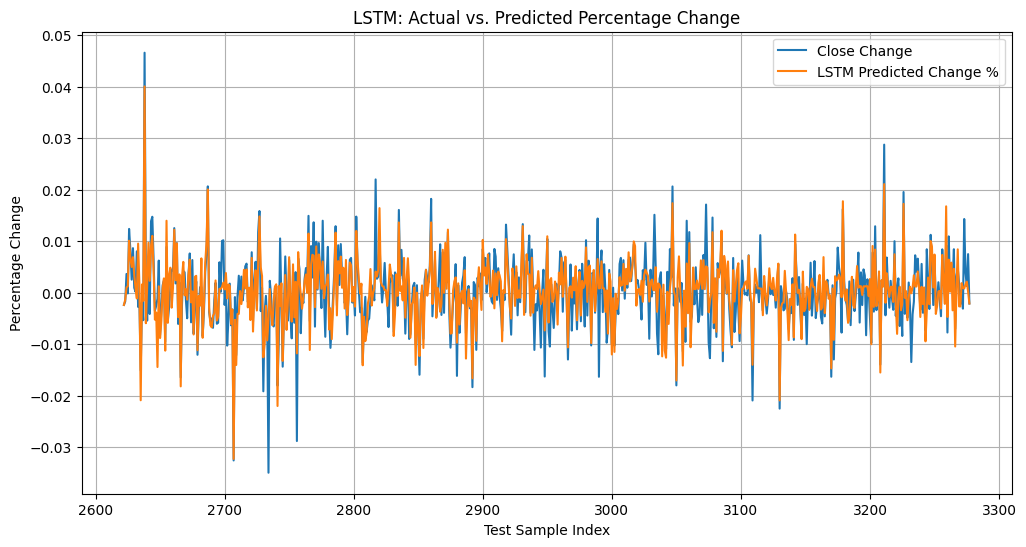

In [71]:
plt.figure(figsize=(12, 6))
plt.plot(test["Pct_Change"], label="Close Change ")
plt.plot(test["pred_change"], label="LSTM Predicted Change %")
plt.title("LSTM: Actual vs. Predicted Percentage Change")
plt.xlabel("Test Sample Index")
plt.ylabel("Percentage Change")
plt.legend()
plt.grid(True)
plt.show()